# Lab: Applications of Principal Component Analysis (PCA)

## Objectives

After completing this lab, you will be able to:

* Use Principal Component Analysis (PCA) to project 2-D data onto its principal axes
* Use PCA for feature space dimensionality reduction
* Relate explained variance to feature importance and noise reduction



## Introduction

In this lab you will explore how to implement two important applications of PCA.

1. The first application illustrates how you can use PCA to project 2-D data onto its principal axes, meaning the two orthogonal directions that explain most of the variance in your data.

2. For the second application, you will use PCA to project higher dimensional data down to a lower dimensional feature space. This is an example of dimension reduction, a powerful technique that has multiple benefits, including reducing your model-building computational load and, in many cases, the accuracy of your model. PCA can help you filter out redundant, linearly correlated variables and reduce the amount of noise in your data.


# Part I: Using PCA to project 2-D data onto its principal axes
Here, you will illustrate how you can use PCA to transform your 2-D data to represent it in terms of its principal axes - the projection of your data onto the two orthogonal directions that explain most of the variance in your data. Let's see what all of this means.


In [1]:
# import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



### Create dataset
Next you'll create a 2-dimensional dataset containing two linearly correlated features.

You'll use a bivariate normal distribution.

Both features, X1 and X2, will have zero mean and a covariance given by the (symmetric) covariance matrix:

\begin{equation}
\begin{pmatrix}
  3  & 2     \\\\\\\\
  2  & 2     \\
\end{pmatrix}
\end{equation}

Here, the diagonal elements define the variances of X1 and X2 (3 and 2, respectively), while the off-diagonal element is the covariance (2) between X1 and X2, which expresses how similarly these features vary.


In [3]:
np.random.seed(42)
mean = [0,0]
cov = [[3,2],[2,2]]
#Generates 200 random data points sampled from this 2D normal distribution, 
# producing an array of shape (200, 2) where:

x = np.random.multivariate_normal(mean = mean, cov= cov, size=200)

### Exercise 1. Visualize the relationship between the two features.
For example, you can use a scatterplot.


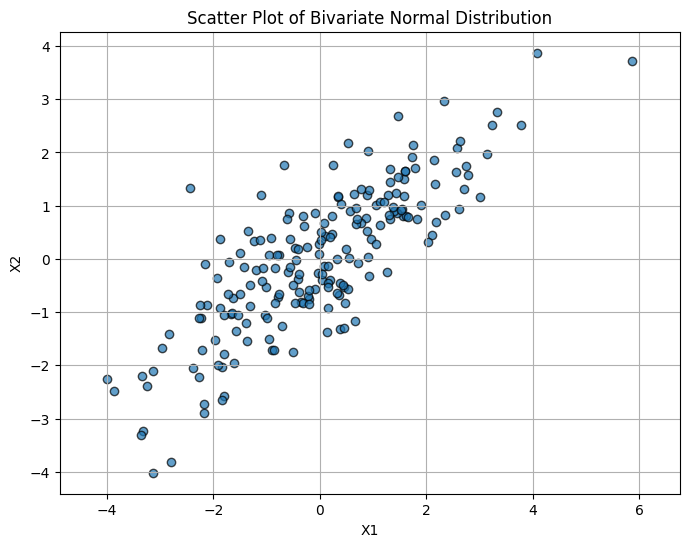

In [4]:
plt.figure(figsize=(8,6))
plt.scatter(x[:,0], x[:,1], edgecolors='k',alpha=0.7)
plt.title("Scatter Plot of Bivariate Normal Distribution")
plt.xlabel("X1")
plt.ylabel("X2")
plt.axis('equal')
plt.grid(True)
plt.show()

Consider the main direction the data follows in the scatterplot. It's actually the direction of the first principal component.
You can use PCA to determine this direction.

###  Perform PCA on the dataset
Next, you'll initialize a 2-component PCA model with default parameters and then fit and transform the feature space in one step.


In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

### Get the principal components from the model. 
The principal components are the principal axes, represented in feature space coordinates, 
which align with the directions of maximum variance in your data. 


In [6]:
components = pca.components_
components

array([[ 0.78215821,  0.62307987],
       [-0.62307987,  0.78215821]])

The principal components are sorted in decreasing order by their explained variance, which can be expressed as a ratio:


In [7]:
pca.explained_variance_ratio_

array([0.9111946, 0.0888054])


You can see that the first component explains over 90% of the variance in the data, while the second explains about 9%.



### Display the results
Here, you'll use a scatterplot to display the data points in their original feature space, X1, X2.

You'll also plot the projections of the data points onto their principal component directions.

It's a bit technical, requiring some understanding of linear algebra, but the outcome will be instructive.

Let's see how this works.

#### Project the data onto its principal component axes
The projection of the data onto a given principal component yields the coordinates of each of the data points along that component's direction. 

The new coordinates are given by the dot products of each point's coordinates with the given PCA component. 

Specifically, the projections are given by:


In [8]:
projection_pc1 = np.dot(x,components[0])
projection_pc2 = np.dot(x, components[1])

Now that you have these coordinates, you can use them to represent the projections of each data point along the principal directions in the original feature space.

In code:


In [9]:
x_pc1 = projection_pc1 *  components[0][0]
y_pc1 = projection_pc1 * components[0][1]
x_pc2 = projection_pc2 * components[1][0]
y_pc2 = projection_pc2 * components[1][1]

### Plot the result


C:\Users\Vish\AppData\Local\Temp\ipykernel_1172\1703533629.py:6: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter (x_pc1, y_pc1, alpha= 0.5, label ="Projection on PC 1", marker='x'
C:\Users\Vish\AppData\Local\Temp\ipykernel_1172\1703533629.py:8: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x_pc2, y_pc2, label = "Peojection on PC 2", marker='x', s= 70, ec = 'k', c = 'b')


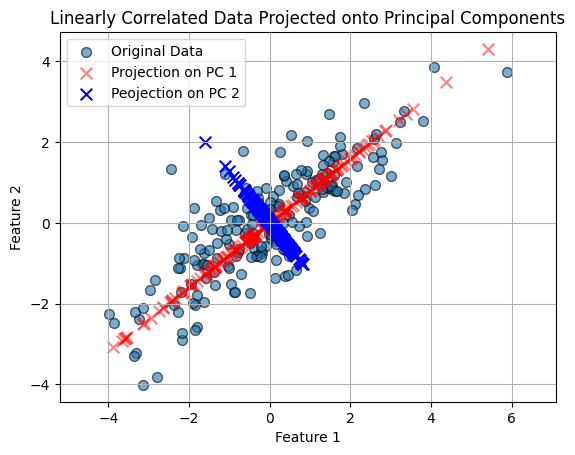

In [11]:
# Plot original data
plt.figure()
plt.scatter(x[:, 0], x[:, 1], label='Original Data', ec='k', s=50, alpha=0.6)

#PCA plots
plt.scatter (x_pc1, y_pc1, alpha= 0.5, label ="Projection on PC 1", marker='x'
             ,c ='r',ec = 'k', s=70)
plt.scatter(x_pc2, y_pc2, label = "Peojection on PC 2", marker='x', s= 70, ec = 'k', c = 'b')
plt.title('Linearly Correlated Data Projected onto Principal Components', )
plt.xlabel('Feature 1',)
plt.ylabel('Feature 2',)
plt.grid(True)
plt.legend()
plt.axis('equal')
plt.show()

# Part II. PCA for feature space dimensionality reduction
For this second application, you'll use PCA to project the four-dimensional Iris feature data set down onto a two-dimensional feature space.

This will have the added benefit of enabling you to visualize some of the most important structures in the dataset.


### Load and preprocess Iris data
Let's start by loading the iris data and standardizing is features.


In [16]:
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
iris = datasets.load_iris()
x = iris.data
y = iris.target
target_names = iris.target_names


# scale the data
scaler = StandardScaler()
x_scale = scaler.fit_transform(x)


### Exercise 5. Initialize a PCA model and reduce the Iris data set dimensionality to two components


In [19]:
pca_iris = PCA(n_components=2)
X_pca = pca_iris.fit_transform(x_scale)

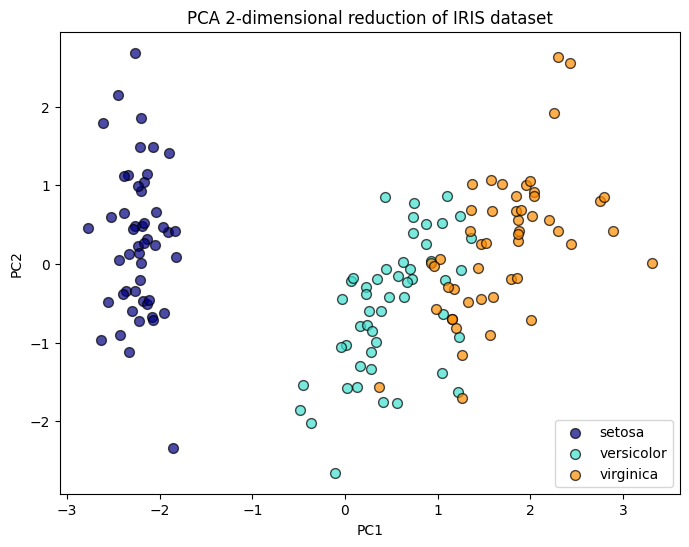

In [20]:
# Plot the PCA-transformed data in 2D
plt.figure(figsize=(8,6))

colors = ['navy', 'turquoise', 'darkorange']
lw = 1

for i, color, target_name in zip([0,1,2], colors, target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y ==i, 1], color = color, s = 50, ec ='k',
                alpha= 0.7, lw = lw, label = target_name)


plt.title('PCA 2-dimensional reduction of IRIS dataset',)
plt.xlabel("PC1",)
plt.ylabel("PC2",)
plt.legend(loc = 'best',shadow = False, scatterpoints = 1)
plt.show() 

### Exercise 6. What percentage of the original feature space variance do these two combined principal components explain?


In [22]:
100*pca_iris.explained_variance_ratio_.sum()

np.float64(95.81320720000166)

## A deeper look at the explained variances
In this next and final set of exercises, your goal is to:
- Acquire and plot the PCA-explained variance ratios for all four Iris features as a barplot
- Overlay the cummulative explained variance

### Exercise 7. Reinitialize the PCA model without reducing the dimension
Standardize the Iris data, and fit and transform the scaled data.


In [47]:
pca_iris_new = PCA(n_components=4)
X_pca_new = pca_iris_new.fit_transform(x_scale)

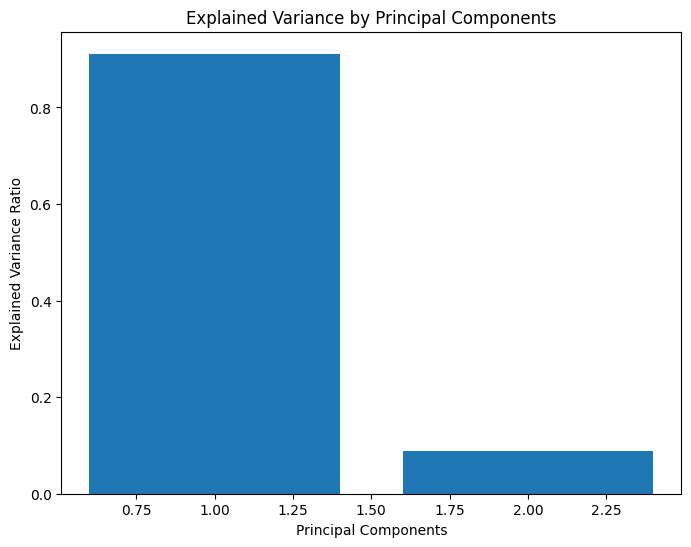

In [48]:
# Explained variance ratio
explain_variance_ratio = pca.explained_variance_ratio_

# Plot explained variance ratio for each component
plt.figure(figsize=(8,6))
plt.bar(x = range(1,len(explain_variance_ratio)+1), height=explain_variance_ratio,
    alpha =1, align='center', label = 'pc explain variance ratio')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.title('Explained Variance by Principal Components')
plt.show()

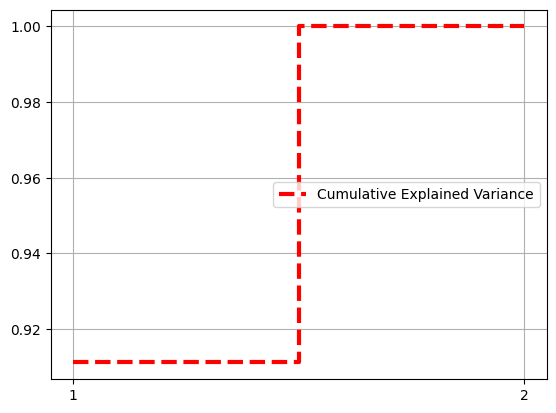

In [49]:
n = len(explain_variance_ratio)  # however many components you have

cumulative_variance_ratio = np.cumsum(explain_variance_ratio)
plt.step(range(1, n + 1), cumulative_variance_ratio, where='mid', 
         linestyle='--', lw=3, color='red', label='Cumulative Explained Variance')
plt.xticks(range(1, n + 1))
plt.legend()
plt.grid(True)
plt.show()